# SG10K VEP-Annotated Data: Statistics, Visualization & Missense Filtering

---

## Objective

This notebook processes **VEP-annotated SG10K South Asian VCF files** to:

1. Parse the VEP `CSQ` field from annotated VCFs
2. Explore variant statistics and generate visualizations
3. Filter for **missense variants** using clinically grounded criteria
4. Save the filtered dataset for downstream bias quantification and model adaptation

### VEP Annotation Details

The VCFs were annotated offline with Ensembl VEP using:
```bash
--offline --cache --assembly GRCh38 --vcf --compress_output bgzip
--symbol --mane --biotype
```

Key flags:
- **`--mane`** (instead of `--canonical`): Uses MANE Select/Plus Clinical transcripts — the ACMG/ClinGen recommended standard for clinical reporting
- **`--symbol`**: Adds gene symbols (e.g., BRCA1)
- **`--biotype`**: Adds transcript biotype (e.g., protein_coding)

### Memory-Efficient Design

This notebook uses a **single-pass streaming approach**:
- Statistics are collected via lightweight `Counter` objects (zero extra RAM)
- Only **missense records** that pass all 4 filters are kept in memory
- Reduces RAM from ~20-40 GB (all annotations) to ~100-500 MB (missense only)

### Input
- VEP-annotated VCFs: `sg10k_chr{N}_SAS_annotated_mane.vcf.gz`
- SAS-filtered + normalized from previous pipeline

---

## 1. Environment Setup

In [1]:
!pip install cyvcf2 -q
!apt-get update -q
!apt-get install -y bcftools tabix -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.1 MB/s eta 0:00:00
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpad

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import warnings
warnings.filterwarnings('ignore')

import os
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cyvcf2 import VCF
from collections import Counter

sns.set_style('whitegrid')
print("All imports ready.")

All imports ready.


## 2. Configuration

In [5]:
# ============================================================
# CONFIGURATION — change CHR to process different chromosomes
# ============================================================
CHR = "22"

INPUT_DIR  = "/content/drive/MyDrive/FYP_DATA/DATA/annotated_data/sg10k/annotated/sg10k_annotated"
INPUT_VCF  = f"{INPUT_DIR}/sg10k_chr{CHR}_SAS_annotated_mane.vcf.gz"

OUTPUT_DIR = "/content/drive/MyDrive/FYP_DATA/DATA"

print(f"Input VCF  : {INPUT_VCF}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"File exists: {os.path.exists(INPUT_VCF)}")

if os.path.exists(INPUT_VCF):
    size_mb = os.path.getsize(INPUT_VCF) / (1024**2)
    print(f"File size  : {size_mb:.2f} MB")

Input VCF  : /content/drive/MyDrive/FYP_DATA/DATA/annotated_data/sg10k/annotated/sg10k_annotated/sg10k_chr22_SAS_annotated_mane.vcf.gz
Output dir : /content/drive/MyDrive/FYP_DATA/DATA
File exists: True
File size  : 187.68 MB


## 3. Parse VEP CSQ Field Format from VCF Header

VEP embeds annotations in the `CSQ` INFO field. The subfield order is defined in the VCF header:
```
##INFO=<ID=CSQ,...,Format: Allele|Consequence|IMPACT|SYMBOL|...>
```
We extract this format string to correctly parse each variant's annotation.

In [6]:
def get_csq_fields(vcf_path):
    """
    Extract CSQ subfield names from the VCF header.
    Returns a list of field names in order.
    """
    vcf = VCF(vcf_path)
    header = vcf.raw_header

    for line in header.split('\n'):
        if 'ID=CSQ' in line:
            # Extract format string after "Format: "
            fmt_start = line.index('Format: ') + len('Format: ')
            fmt_end = line.index('">')
            fmt_string = line[fmt_start:fmt_end]
            fields = fmt_string.split('|')
            return fields

    raise ValueError("CSQ field not found in VCF header. Is this VEP-annotated?")

csq_fields = get_csq_fields(INPUT_VCF)
print(f"CSQ has {len(csq_fields)} subfields:")
for i, field in enumerate(csq_fields):
    print(f"  [{i:2d}] {field}")

CSQ has 27 subfields:
  [ 0] Allele
  [ 1] Consequence
  [ 2] IMPACT
  [ 3] SYMBOL
  [ 4] Gene
  [ 5] Feature_type
  [ 6] Feature
  [ 7] BIOTYPE
  [ 8] EXON
  [ 9] INTRON
  [10] HGVSc
  [11] HGVSp
  [12] cDNA_position
  [13] CDS_position
  [14] Protein_position
  [15] Amino_acids
  [16] Codons
  [17] Existing_variation
  [18] DISTANCE
  [19] STRAND
  [20] FLAGS
  [21] SYMBOL_SOURCE
  [22] HGNC_ID
  [23] CANONICAL
  [24] MANE
  [25] MANE_SELECT
  [26] MANE_PLUS_CLINICAL


## 4. Single-Pass Streaming: Statistics + Missense Extraction

Instead of loading ALL transcript annotations into RAM (which crashes Colab), we:
1. **Stream** through the VCF once
2. **Collect statistics** using lightweight counters (consequence counts, impact counts, biotype counts, etc.)
3. **Keep only missense records** that pass all 4 filters — only these go into memory

This reduces RAM usage from ~20-40 GB (all annotations) to ~100-500 MB (missense only).

In [7]:
def stream_vep_vcf(vcf_path, csq_fields):
    """
    Single-pass streaming parser:
    - Collects statistics via counters (zero RAM overhead)
    - Only keeps missense + protein_coding + MANE Select records
    Returns: (stats_dict, missense_records_list)
    """
    vcf = VCF(vcf_path)

    # --- Precompute field indices for speed ---
    idx = {f: csq_fields.index(f) for f in csq_fields}
    cons_idx     = idx.get('Consequence')
    impact_idx   = idx.get('IMPACT')
    biotype_idx  = idx.get('BIOTYPE')
    symbol_idx   = idx.get('SYMBOL')

    # Find MANE_SELECT index (could be MANE_SELECT or MANE_PLUS_CLINICAL)
    mane_select_idx = None
    mane_plus_idx   = None
    for i, f in enumerate(csq_fields):
        if f.upper() == 'MANE_SELECT':
            mane_select_idx = i
        if f.upper() == 'MANE_PLUS_CLINICAL':
            mane_plus_idx = i

    # --- Lightweight counters for statistics ---
    consequence_counter = Counter()  # exploded by &
    impact_counter      = Counter()
    biotype_counter     = Counter()
    gene_set            = set()
    mane_select_count   = 0
    mane_plus_count     = 0
    variant_keys        = set()      # unique (chrom, pos, ref, alt)
    snp_count           = 0
    indel_count         = 0
    total_annotations   = 0

    # --- Filtering counters ---
    filter_all_missense       = 0
    filter_protein_coding     = 0
    filter_mane               = 0
    filter_moderate           = 0

    # --- Only missense records kept in memory ---
    missense_records = []
    seen_missense_keys = set()  # for dedup: (chrom, pos, ref, alt, symbol)

    variant_count = 0

    print("Streaming VEP-annotated VCF (single pass)...")
    print("=" * 60)

    for variant in vcf:
        variant_count += 1

        chrom = variant.CHROM
        pos   = variant.POS
        ref   = variant.REF
        alt   = variant.ALT[0] if variant.ALT else ''

        vkey = (chrom, pos, ref, alt)
        is_new_variant = vkey not in variant_keys
        if is_new_variant:
            variant_keys.add(vkey)
            # Count SNP vs INDEL at variant level
            if len(ref) == 1 and len(alt) == 1:
                snp_count += 1
            else:
                indel_count += 1

        csq_str = variant.INFO.get('CSQ')
        if csq_str is None:
            continue

        for transcript_csq in csq_str.split(','):
            values = transcript_csq.split('|')
            total_annotations += 1

            # --- Gather stats from every annotation ---
            consequence = values[cons_idx] if cons_idx is not None and cons_idx < len(values) else ''
            impact      = values[impact_idx] if impact_idx is not None and impact_idx < len(values) else ''
            biotype     = values[biotype_idx] if biotype_idx is not None and biotype_idx < len(values) else ''
            symbol      = values[symbol_idx] if symbol_idx is not None and symbol_idx < len(values) else ''
            mane_select = values[mane_select_idx] if mane_select_idx is not None and mane_select_idx < len(values) else ''
            mane_plus   = values[mane_plus_idx] if mane_plus_idx is not None and mane_plus_idx < len(values) else ''

            # Consequence counter (explode by &)
            for c in consequence.split('&'):
                if c:
                    consequence_counter[c] += 1

            if impact:
                impact_counter[impact] += 1
            if biotype:
                biotype_counter[biotype] += 1
            if symbol:
                gene_set.add(symbol)
            if mane_select:
                mane_select_count += 1
            if mane_plus:
                mane_plus_count += 1

            # --- MISSENSE FILTER (in-stream) ---
            # Filter 1: consequence contains missense_variant
            if 'missense_variant' not in consequence:
                continue
            filter_all_missense += 1

            # Filter 2: protein_coding
            if biotype != 'protein_coding':
                continue
            filter_protein_coding += 1

            # Filter 3: MANE Select
            if not mane_select:
                continue
            filter_mane += 1

            # Filter 4: MODERATE impact
            if impact != 'MODERATE':
                continue
            filter_moderate += 1

            # Dedup by (chrom, pos, ref, alt, symbol)
            dedup_key = (chrom, pos, ref, alt, symbol)
            if dedup_key in seen_missense_keys:
                continue
            seen_missense_keys.add(dedup_key)

            # Build record — only for missense that passed all filters
            record = {
                'CHROM': chrom,
                'POS': pos,
                'REF': ref,
                'ALT': alt,
            }
            for i, field_name in enumerate(csq_fields):
                record[field_name] = values[i] if i < len(values) else ''

            missense_records.append(record)

        if variant_count % 100000 == 0:
            print(f"  {variant_count:>10,} variants streamed | {len(missense_records):,} missense kept")

    # --- Compile stats ---
    stats = {
        'variant_count': variant_count,
        'unique_variants': len(variant_keys),
        'total_annotations': total_annotations,
        'snp_count': snp_count,
        'indel_count': indel_count,
        'unique_genes': len(gene_set),
        'consequence_counter': consequence_counter,
        'impact_counter': impact_counter,
        'biotype_counter': biotype_counter,
        'mane_select_count': mane_select_count,
        'mane_plus_count': mane_plus_count,
        'filter_all_missense': filter_all_missense,
        'filter_protein_coding': filter_protein_coding,
        'filter_mane': filter_mane,
        'filter_moderate': filter_moderate,
        'final_missense': len(missense_records),
    }

    print(f"\n{'=' * 60}")
    print(f"Streaming complete!")
    print(f"   VCF variants streamed   : {variant_count:,}")
    print(f"   Unique variants         : {stats['unique_variants']:,}")
    print(f"   Total annotations       : {total_annotations:,}")
    print(f"   Missense kept in memory : {len(missense_records):,}")
    print(f"{'=' * 60}")

    return stats, missense_records

stats, missense_records = stream_vep_vcf(INPUT_VCF, csq_fields)

Streaming VEP-annotated VCF (single pass)...
     100,000 variants streamed | 660 missense kept
     200,000 variants streamed | 2,166 missense kept
     300,000 variants streamed | 2,990 missense kept
     400,000 variants streamed | 3,781 missense kept
     500,000 variants streamed | 4,558 missense kept
     600,000 variants streamed | 5,831 missense kept
     700,000 variants streamed | 5,951 missense kept
     800,000 variants streamed | 7,265 missense kept
     900,000 variants streamed | 8,450 missense kept
   1,000,000 variants streamed | 9,722 missense kept
   1,100,000 variants streamed | 10,400 missense kept
   1,200,000 variants streamed | 10,973 missense kept
   1,300,000 variants streamed | 11,849 missense kept

Streaming complete!
   VCF variants streamed   : 1,339,154
   Unique variants         : 1,339,154
   Total annotations       : 17,370,813
   Missense kept in memory : 12,513


In [8]:
# Convert only the missense records to DataFrame (small, fits in RAM)
df_missense = pd.DataFrame(missense_records)
del missense_records  # free the list

print(f"Missense DataFrame shape: {df_missense.shape}")
print(f"Columns: {df_missense.columns.tolist()}")
df_missense.head()

Missense DataFrame shape: (12513, 31)
Columns: ['CHROM', 'POS', 'REF', 'ALT', 'Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Gene', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'HGVSc', 'HGVSp', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'Existing_variation', 'DISTANCE', 'STRAND', 'FLAGS', 'SYMBOL_SOURCE', 'HGNC_ID', 'CANONICAL', 'MANE', 'MANE_SELECT', 'MANE_PLUS_CLINICAL']


,CHROM,POS,REF,ALT,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,...,Existing_variation,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL
0,chr22,16590890,G,A,A,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
1,chr22,16590909,G,T,T,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
2,chr22,16590924,C,T,T,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
3,chr22,16590972,C,A,A,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
4,chr22,16590995,G,A,A,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,


In [9]:
df_missense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12513 entries, 0 to 12512
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CHROM               12513 non-null  object
 1   POS                 12513 non-null  int64 
 2   REF                 12513 non-null  object
 3   ALT                 12513 non-null  object
 4   Allele              12513 non-null  object
 5   Consequence         12513 non-null  object
 6   IMPACT              12513 non-null  object
 7   SYMBOL              12513 non-null  object
 8   Gene                12513 non-null  object
 9   Feature_type        12513 non-null  object
 10  Feature             12513 non-null  object
 11  BIOTYPE             12513 non-null  object
 12  EXON                12513 non-null  object
 13  INTRON              12513 non-null  object
 14  HGVSc               12513 non-null  object
 15  HGVSp               12513 non-null  object
 16  cDNA_position       12

## 5. Overview Statistics (from streaming counters — zero extra RAM)

All statistics below were collected during the single streaming pass.

In [10]:
# ============================================================
# BASIC COUNTS (from stats dict, not DataFrame)
# ============================================================
print("=" * 60)
print(f"  DATASET OVERVIEW — chr{CHR}")
print("=" * 60)
print(f"  VCF variants streamed    : {stats['variant_count']:,}")
print(f"  Unique variants          : {stats['unique_variants']:,}")
print(f"  Total transcript annot.  : {stats['total_annotations']:,}")
print(f"  Annotations per variant  : {stats['total_annotations'] / max(stats['unique_variants'],1):.2f} (avg)")
print(f"  Unique genes (SYMBOL)    : {stats['unique_genes']:,}")
print(f"  SNPs                     : {stats['snp_count']:,}")
print(f"  INDELs                   : {stats['indel_count']:,}")
print("=" * 60)

  DATASET OVERVIEW — chr22
  VCF variants streamed    : 1,339,154
  Unique variants          : 1,339,154
  Total transcript annot.  : 17,370,813
  Annotations per variant  : 12.97 (avg)
  Unique genes (SYMBOL)    : 934
  SNPs                     : 1,212,323
  INDELs                   : 126,831


### 5.1 Consequence Type Distribution

VEP assigns one or more **Sequence Ontology (SO)** consequence terms to each variant-transcript pair.
A single annotation can have multiple consequences joined by `&` (e.g., `missense_variant&splice_region_variant`).

In [11]:
# From streaming counters — already exploded by &
consequence_counts = pd.Series(stats['consequence_counter']).sort_values(ascending=False)

print(f"Total unique consequence types: {len(consequence_counts)}")
print(f"\nTop 20 consequences:")
print(consequence_counts.head(20).to_string())

Total unique consequence types: 29

Top 20 consequences:
intron_variant                         12253082
non_coding_transcript_variant           3829978
downstream_gene_variant                 2088475
upstream_gene_variant                   2076698
NMD_transcript_variant                   589462
non_coding_transcript_exon_variant       229915
3_prime_UTR_variant                      177733
intergenic_variant                       171269
missense_variant                         150902
synonymous_variant                       119380
5_prime_UTR_variant                       48432
splice_polypyrimidine_tract_variant       46830
splice_region_variant                     42976
frameshift_variant                        26781
stop_gained                               10772
splice_donor_region_variant                8987
splice_acceptor_variant                    7604
splice_donor_variant                       5983
inframe_deletion                           3879
splice_donor_5th_base_variant  

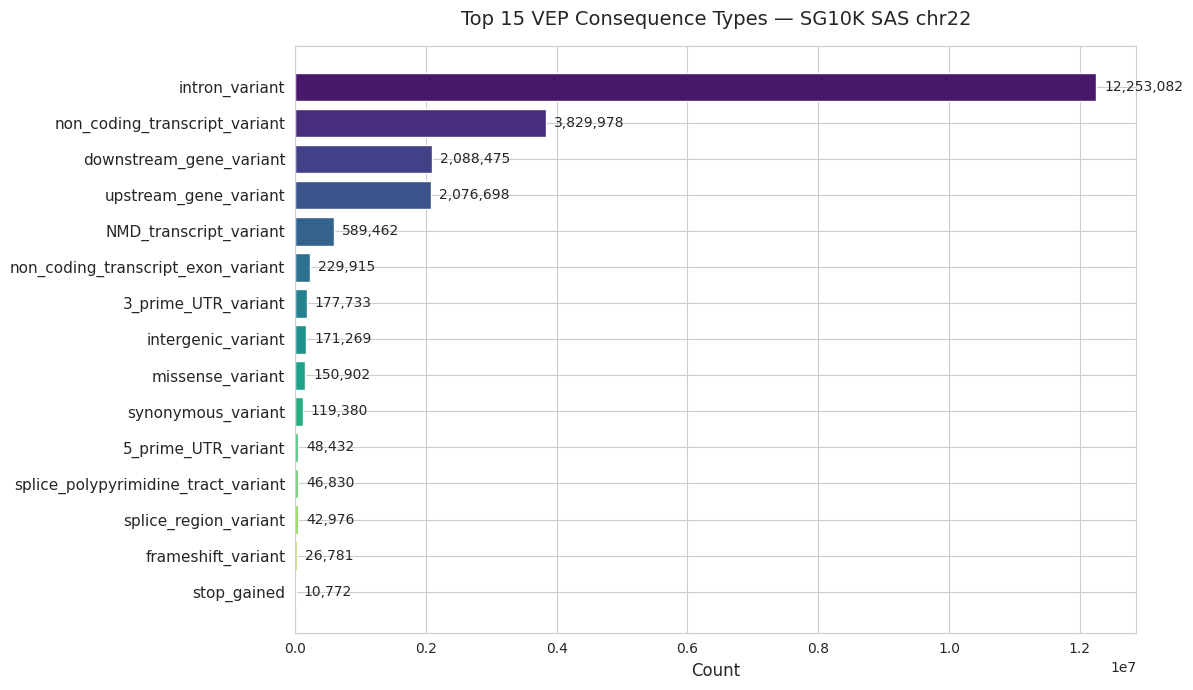

In [12]:
# ---- PLOT: Top 15 consequence types ----
top_n = 15
top_consequences = consequence_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top_consequences)), top_consequences.values, color=sns.color_palette('viridis', top_n))
ax.set_yticks(range(len(top_consequences)))
ax.set_yticklabels(top_consequences.index, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Count', fontsize=12)
ax.set_title(f'Top {top_n} VEP Consequence Types — SG10K SAS chr{CHR}', fontsize=14, pad=15)

# Add count labels on bars
for bar, count in zip(bars, top_consequences.values):
    ax.text(bar.get_width() + max(top_consequences.values) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 5.2 IMPACT Distribution

VEP assigns an **IMPACT** rating to each consequence:
- **HIGH**: frameshift, stop gained, splice donor/acceptor
- **MODERATE**: missense, inframe insertion/deletion
- **LOW**: synonymous, splice region
- **MODIFIER**: intronic, intergenic, UTR, regulatory

IMPACT distribution:
  MODIFIER     : 16,974,045  (97.7%)
  LOW          :    189,119  (1.1%)
  HIGH         :     51,650  (0.3%)
  MODERATE     :    155,999  (0.9%)


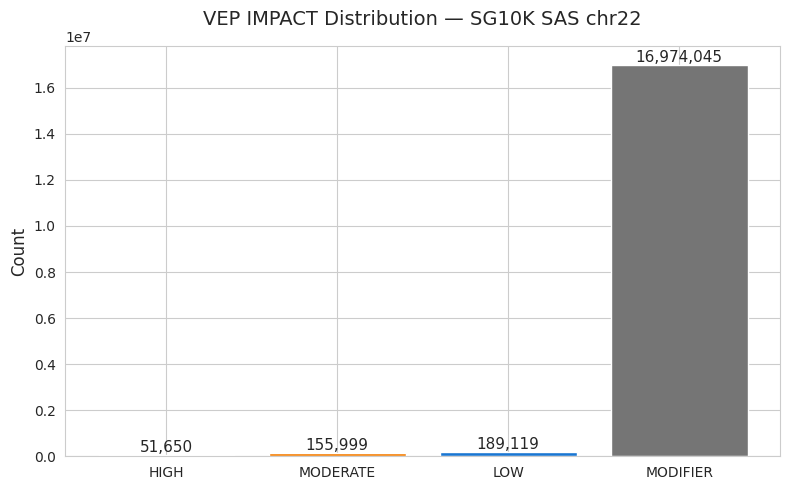

In [13]:
impact_counts = pd.Series(stats['impact_counter'])

if not impact_counts.empty:
    print("IMPACT distribution:")
    total = impact_counts.sum()
    for impact, count in impact_counts.items():
        pct = count / total * 100
        print(f"  {impact:12s} : {count:>10,}  ({pct:.1f}%)")

    # Plot
    colors = {'HIGH': '#d32f2f', 'MODERATE': '#f57c00', 'LOW': '#1976d2', 'MODIFIER': '#757575'}
    fig, ax = plt.subplots(figsize=(8, 5))
    impact_order = ['HIGH', 'MODERATE', 'LOW', 'MODIFIER']
    impact_ordered = impact_counts.reindex(impact_order).dropna()
    bars = ax.bar(impact_ordered.index, impact_ordered.values,
                  color=[colors.get(x, 'gray') for x in impact_ordered.index])
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'VEP IMPACT Distribution — SG10K SAS chr{CHR}', fontsize=14, pad=15)

    for bar, count in zip(bars, impact_ordered.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{count:,}', ha='center', va='bottom', fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print("No IMPACT data collected.")

### 5.3 Biotype Distribution

Shows which transcript types the variants fall on.

Top 15 Biotypes:
  protein_coding                 : 10,329,789
  lncRNA                         :  4,673,083
  nonsense_mediated_decay        :    743,719
  retained_intron                :    699,121
  protein_coding_CDS_not_defined :    520,453
  processed_pseudogene           :     54,818
  transcribed_unprocessed_pseudogene :     37,299
  unprocessed_pseudogene         :     24,997
  misc_RNA                       :     23,308
  IG_V_pseudogene                :     18,017
  miRNA                          :     16,985
  IG_V_gene                      :     15,194
  snRNA                          :      8,317
  transcribed_processed_pseudogene :      7,522
  TEC                            :      4,596


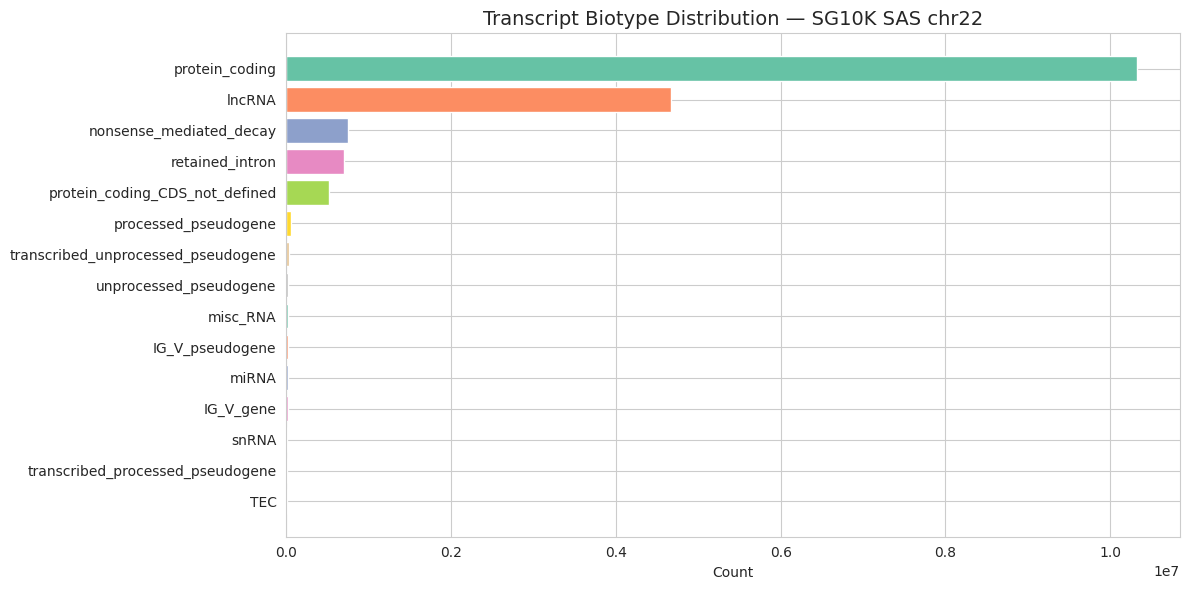

In [14]:
biotype_counts = pd.Series(stats['biotype_counter']).sort_values(ascending=False).head(15)

if not biotype_counts.empty:
    print("Top 15 Biotypes:")
    for bt, count in biotype_counts.items():
        print(f"  {bt:30s} : {count:>10,}")

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(range(len(biotype_counts)), biotype_counts.values, color=sns.color_palette('Set2', len(biotype_counts)))
    ax.set_yticks(range(len(biotype_counts)))
    ax.set_yticklabels(biotype_counts.index)
    ax.invert_yaxis()
    ax.set_xlabel('Count')
    ax.set_title(f'Transcript Biotype Distribution — SG10K SAS chr{CHR}', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No BIOTYPE data collected.")

### 5.4 MANE Transcript Coverage

How many annotations come from MANE Select vs MANE Plus Clinical transcripts?

In [15]:
total = stats['total_annotations']
print(f"MANE transcript coverage (out of {total:,} total annotations):")
print(f"\n  MANE_SELECT:")
print(f"    Count     : {stats['mane_select_count']:,} ({stats['mane_select_count']/max(total,1)*100:.1f}%)")
print(f"\n  MANE_PLUS_CLINICAL:")
print(f"    Count     : {stats['mane_plus_count']:,} ({stats['mane_plus_count']/max(total,1)*100:.1f}%)")

MANE transcript coverage (out of 17,370,813 total annotations):

  MANE_SELECT:
    Count     : 816,064 (4.7%)

  MANE_PLUS_CLINICAL:
    Count     : 0 (0.0%)


### 5.5 Variant Type (SNP vs INDEL)

Variant Types:
  SNP    :  1,212,323  (90.5%)
  INDEL  :    126,831  (9.5%)


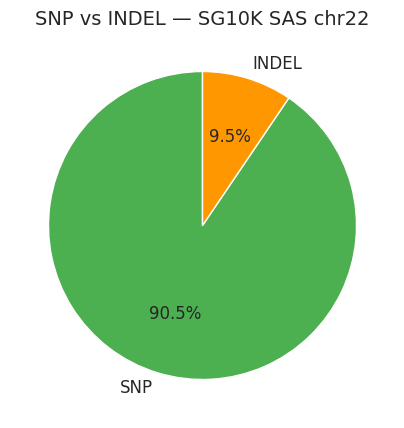

In [16]:
# From streaming counters
type_counts = pd.Series({'SNP': stats['snp_count'], 'INDEL': stats['indel_count']})
print("Variant Types:")
total_vars = type_counts.sum()
for vtype, count in type_counts.items():
    pct = count / max(total_vars, 1) * 100
    print(f"  {vtype:6s} : {count:>10,}  ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
       colors=['#4CAF50', '#FF9800'], startangle=90, textprops={'fontsize': 12})
ax.set_title(f'SNP vs INDEL — SG10K SAS chr{CHR}', fontsize=14)
plt.show()

### 5.6 Top Genes by Missense Variant Count

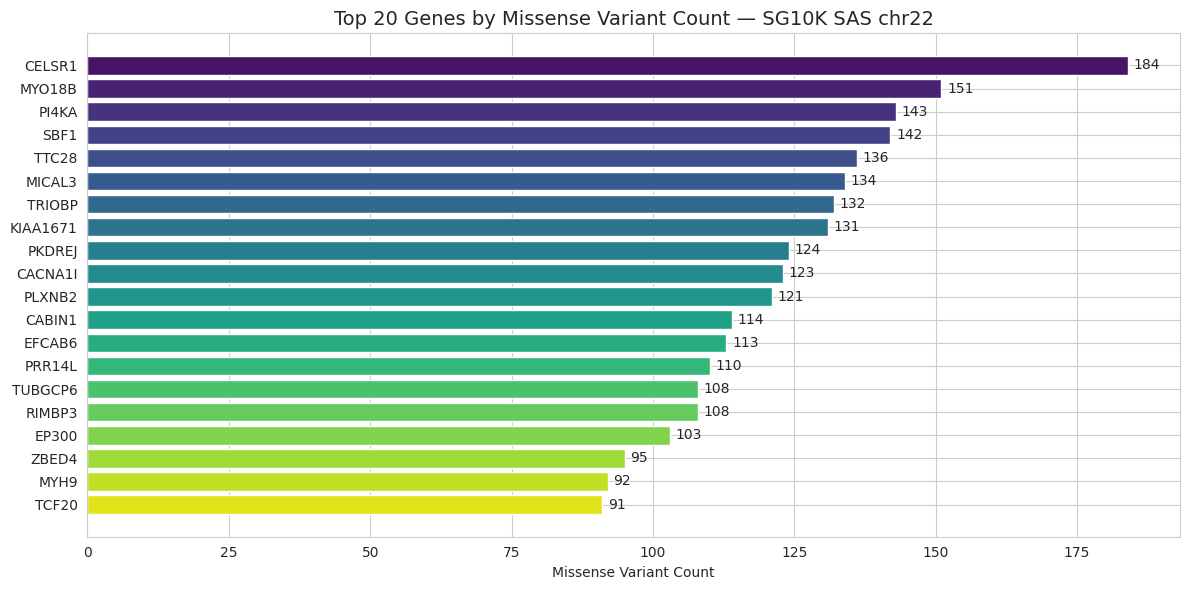

In [17]:
# Top genes by MISSENSE variant count (from filtered df — already small)
if 'SYMBOL' in df_missense.columns:
    gene_variant_counts = df_missense['SYMBOL'].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(range(len(gene_variant_counts)), gene_variant_counts.values, color=sns.color_palette('viridis', len(gene_variant_counts)))
    ax.set_yticks(range(len(gene_variant_counts)))
    ax.set_yticklabels(gene_variant_counts.index)
    ax.invert_yaxis()
    ax.set_xlabel('Missense Variant Count')
    ax.set_title(f'Top 20 Genes by Missense Variant Count — SG10K SAS chr{CHR}', fontsize=14)

    for bar, count in zip(ax.patches, gene_variant_counts.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{count:,}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

---

## 6. Missense Filtering — Criteria Discussion

### Why Filter for Missense?

Your FYP focuses on **missense variant effect prediction**. Missense variants:
- Cause a **single amino acid substitution** in the protein
- Are the most common type of pathogenic coding variant
- Are what predictors like AlphaMissense, EVE, REVEL, ESM-1b are designed to score

### Filtering Criteria

We apply **four filters** in sequence:

| # | Filter | Rationale |
|---|--------|----------|
| 1 | **Consequence = `missense_variant`** | VEP SO term for single amino acid change. We include annotations where `missense_variant` appears anywhere in the Consequence field (since VEP can assign compound terms like `missense_variant&splice_region_variant`) |
| 2 | **BIOTYPE = `protein_coding`** | Only protein-coding transcripts produce proteins. Missense on non-coding transcripts (pseudogenes, lncRNA) are biologically irrelevant |
| 3 | **MANE Select transcript** | ACMG/ClinGen standard. Ensures one canonical annotation per gene. Avoids inflation from multiple transcript annotations of the same variant. This is why we used `--mane` in VEP |
| 4 | **IMPACT = `MODERATE`** | Missense variants always have MODERATE impact in VEP. This is a sanity check — if a "missense" has HIGH impact, something is wrong |

### What About Compound Consequences?

VEP can assign compound consequences like:
- `missense_variant&splice_region_variant` — missense AND near a splice site
- `missense_variant&NMD_transcript_variant` — missense in an NMD-targeted transcript

**Our approach:** Keep any annotation where `missense_variant` is present in the Consequence field. The `&splice_region_variant` part is additional context, not a different variant type. The variant still causes a single amino acid change.

### Why NOT filter by:

| Excluded filter | Reason |
|----------------|--------|
| Allele frequency | We're building a population-aware predictor — we need ALL missense variants regardless of frequency (rare, common, ultra-rare) |
| Gene list | We're benchmarking genome-wide, not targeted |
| Quality score | VCF QUAL filtering was already done during SAS filtering/normalization |

---

## 7. Missense Filtering Summary

The filtering was performed **during streaming** (Section 4). This section displays the funnel results.

In [18]:
# Filtering was already done during streaming!
# Show the filtering funnel from stats
print("=" * 70)
print(f"  MISSENSE FILTERING SUMMARY — chr{CHR}")
print("=" * 70)
print(f"\n  Total transcript annotations streamed : {stats['total_annotations']:,}")
print(f"\n  [1] Consequence contains 'missense_variant'")
print(f"      Passed: {stats['filter_all_missense']:,}")
print(f"\n  [2] BIOTYPE = protein_coding")
print(f"      Passed: {stats['filter_protein_coding']:,}")
print(f"\n  [3] MANE Select transcript")
print(f"      Passed: {stats['filter_mane']:,}")
print(f"\n  [4] IMPACT = MODERATE")
print(f"      Passed: {stats['filter_moderate']:,}")
print(f"\n  [5] Deduplicated (CHROM, POS, REF, ALT, SYMBOL)")
print(f"      Final : {len(df_missense):,}")

print(f"\n{'=' * 70}")
print(f"  FINAL MISSENSE COUNT: {len(df_missense):,}")
print(f"  Unique genes: {df_missense['SYMBOL'].nunique() if 'SYMBOL' in df_missense.columns else 'N/A'}")
print(f"{'=' * 70}")

  MISSENSE FILTERING SUMMARY — chr22

  Total transcript annotations streamed : 17,370,813

  [1] Consequence contains 'missense_variant'
      Passed: 150,902

  [2] BIOTYPE = protein_coding
      Passed: 145,970

  [3] MANE Select transcript
      Passed: 12,513

  [4] IMPACT = MODERATE
      Passed: 12,513

  [5] Deduplicated (CHROM, POS, REF, ALT, SYMBOL)
      Final : 12,513

  FINAL MISSENSE COUNT: 12,513
  Unique genes: 420


## 8. Missense Statistics & Visualizations

In [19]:
# ---- Consequence breakdown within missense ----
print("Consequence terms in filtered missense set:")
missense_consequences = df_missense['Consequence'].value_counts()
for cons, count in missense_consequences.items():
    pct = count / len(df_missense) * 100
    print(f"  {cons:50s} : {count:>8,}  ({pct:.1f}%)")

Consequence terms in filtered missense set:
  missense_variant                                   :   12,106  (96.7%)
  missense_variant&splice_region_variant             :      407  (3.3%)


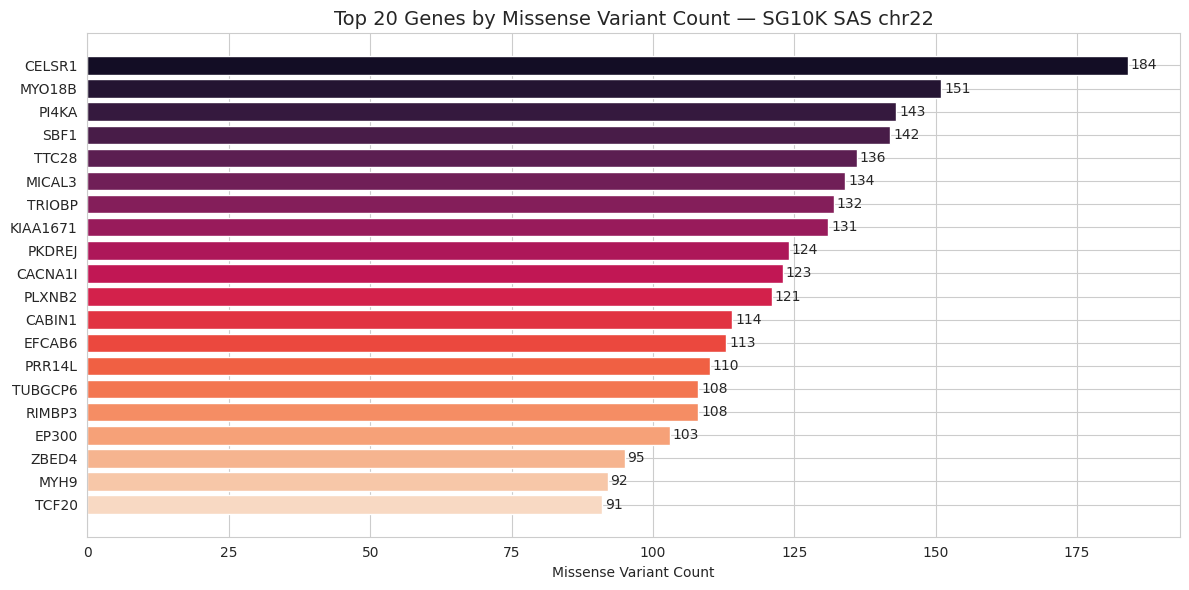

In [20]:
# ---- Top genes with most missense variants ----
if 'SYMBOL' in df_missense.columns:
    missense_gene_counts = df_missense['SYMBOL'].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(range(len(missense_gene_counts)), missense_gene_counts.values,
            color=sns.color_palette('rocket', len(missense_gene_counts)))
    ax.set_yticks(range(len(missense_gene_counts)))
    ax.set_yticklabels(missense_gene_counts.index)
    ax.invert_yaxis()
    ax.set_xlabel('Missense Variant Count')
    ax.set_title(f'Top 20 Genes by Missense Variant Count — SG10K SAS chr{CHR}', fontsize=14)

    for bar, count in zip(ax.patches, missense_gene_counts.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{count:,}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

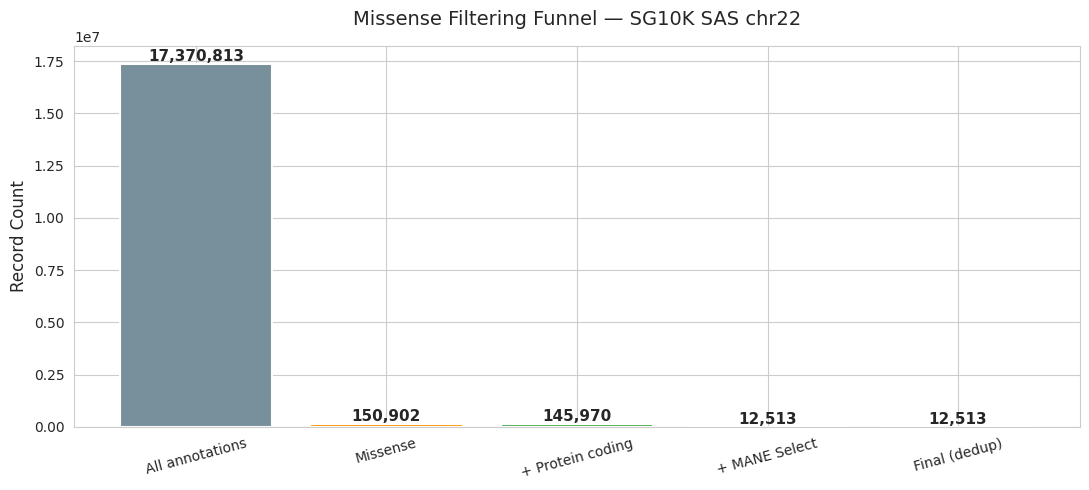

In [21]:
# ---- Filtering funnel visualization (from stats counters) ----
funnel_counts = [
    stats['total_annotations'],
    stats['filter_all_missense'],
    stats['filter_protein_coding'],
    stats['filter_mane'],
    len(df_missense)
]
funnel_names = ['All annotations', 'Missense', '+ Protein coding', '+ MANE Select', 'Final (dedup)']

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#78909C', '#FF9800', '#4CAF50', '#7B1FA2', '#1976D2']
bars = ax.bar(funnel_names, funnel_counts, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Record Count', fontsize=12)
ax.set_title(f'Missense Filtering Funnel — SG10K SAS chr{CHR}', fontsize=14, pad=15)

for bar, count in zip(bars, funnel_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(fontsize=10, rotation=15)
plt.tight_layout()
plt.show()

## 9. Save Filtered Missense Data

In [22]:
import pickle

# ---- Save as CSV ----
output_csv = f"{OUTPUT_DIR}/sg10k_chr{CHR}_SAS_missense.csv"
df_missense.to_csv(output_csv, index=False)
csv_size = os.path.getsize(output_csv) / (1024**2)
print(f"CSV saved: {output_csv}")
print(f"   Size: {csv_size:.2f} MB")

# ---- Save as pickle ----
output_pkl = f"{OUTPUT_DIR}/sg10k_chr{CHR}_SAS_missense.pkl"
with open(output_pkl, 'wb') as f:
    pickle.dump(df_missense, f, protocol=pickle.HIGHEST_PROTOCOL)
pkl_size = os.path.getsize(output_pkl) / (1024**2)
print(f"Pickle saved: {output_pkl}")
print(f"   Size: {pkl_size:.2f} MB")

print(f"\nFinal missense dataset:")
print(f"   Shape   : {df_missense.shape}")
print(f"   Columns : {list(df_missense.columns)}")

CSV saved: /content/drive/MyDrive/FYP_DATA/DATA/sg10k_chr22_SAS_missense.csv
   Size: 2.34 MB
Pickle saved: /content/drive/MyDrive/FYP_DATA/DATA/sg10k_chr22_SAS_missense.pkl
   Size: 3.23 MB

Final missense dataset:
   Shape   : (12513, 31)
   Columns : ['CHROM', 'POS', 'REF', 'ALT', 'Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Gene', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'HGVSc', 'HGVSp', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'Existing_variation', 'DISTANCE', 'STRAND', 'FLAGS', 'SYMBOL_SOURCE', 'HGNC_ID', 'CANONICAL', 'MANE', 'MANE_SELECT', 'MANE_PLUS_CLINICAL']


## 10. Quick Sanity Checks

In [23]:
print("=" * 60)
print("  SANITY CHECKS")
print("=" * 60)

# Check 1: All entries are missense
all_missense = df_missense['Consequence'].str.contains('missense_variant', na=False).all()
print(f"  All entries contain 'missense_variant' : {'PASS' if all_missense else 'FAIL'}")

# Check 2: All are protein_coding
if 'BIOTYPE' in df_missense.columns:
    all_pc = (df_missense['BIOTYPE'] == 'protein_coding').all()
    print(f"  All entries are protein_coding        : {'PASS' if all_pc else 'FAIL'}")

# Check 3: All are MODERATE impact
if 'IMPACT' in df_missense.columns:
    all_mod = (df_missense['IMPACT'] == 'MODERATE').all()
    print(f"  All entries have MODERATE impact       : {'PASS' if all_mod else 'FAIL'}")

# Check 4: MANE Select populated
mane_select_col = next((c for c in df_missense.columns if 'MANE_SELECT' in c.upper()), None)
if mane_select_col:
    all_mane = (df_missense[mane_select_col] != '').all()
    print(f"  All entries have MANE Select           : {'PASS' if all_mane else 'FAIL'}")

# Check 5: No duplicate variant-gene pairs
n_dupes = df_missense.duplicated(subset=['CHROM', 'POS', 'REF', 'ALT', 'SYMBOL']).sum()
print(f"  No duplicate (variant, gene) pairs     : {'PASS' if n_dupes == 0 else f'FAIL ({n_dupes} duplicates)'}")

print("=" * 60)

  SANITY CHECKS
  All entries contain 'missense_variant' : PASS
  All entries are protein_coding        : PASS
  All entries have MODERATE impact       : PASS
  All entries have MANE Select           : PASS
  No duplicate (variant, gene) pairs     : PASS


In [24]:
# Preview final data
df_missense.head(10)

,CHROM,POS,REF,ALT,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,...,Existing_variation,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL
0,chr22,16590890,G,A,A,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
1,chr22,16590909,G,T,T,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
2,chr22,16590924,C,T,T,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
3,chr22,16590972,C,A,A,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
4,chr22,16590995,G,A,A,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
5,chr22,16591004,G,A,A,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
6,chr22,16591145,C,G,G,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
7,chr22,16591221,T,A,A,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
8,chr22,16591238,T,C,C,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,
9,chr22,16591284,C,T,T,missense_variant,MODERATE,CCT8L2,ENSG00000198445,Transcript,...,,,-1,,HGNC,HGNC:15553,YES,MANE_Select,NM_014406.5,


In [34]:
impact = df_missense['IMPACT']

In [37]:
impact = pd.DataFrame(impact)
impact.head()

,IMPACT
0,MODERATE
1,MODERATE
2,MODERATE
3,MODERATE
4,MODERATE


In [46]:
print(f"Unique values in IMPACT column: {impact['IMPACT'].unique()}")

Unique values in IMPACT column: ['MODERATE']
